# Did splitting grammy.com and recordingacademy.com actually work?

**Analyst:** Maurice Colbert Jr. · **Stack:** Python, pandas, matplotlib

## The situation

The Recording Academy runs two web properties. Until February 1, 2022 they were a
single site. On that date the organization split the domain in two: `grammy.com`
for awards-show content aimed at music fans, and `recordingacademy.com` for
industry content aimed at members, voters, and professionals.

Leadership wanted to know whether that split was worth keeping. The question I was
handed was deliberately open-ended — "did the split improve engagement?" — so the
first thing I had to do was turn it into something measurable.

## How I framed the question

Raw traffic totals cannot answer this. The Grammys site is dominated by one night a
year, so any before/after comparison of totals mostly measures *when the ceremony
fell*, not whether the site got better. So I built the analysis around **per-session
ratio metrics**, which are insensitive to traffic volume:

| Metric | Definition | What it tells me |
|---|---|---|
| Bounce rate | `bounced_sessions / sessions` | Did the landing page give people a reason to stay? |
| Pages per session | `pageviews / sessions` | Did visitors go deeper than one page? |
| Avg time on site | mean of `avg_session_duration_secs` | Did the content hold attention? |

I then answered four questions in order, each one motivated by what the previous
answer exposed:

1. How concentrated is Grammys traffic? (Establishes why ratio metrics are required.)
2. Did engagement improve on the Grammys site after the split?
3. Is the Recording Academy site actually serving a different audience, or the same
   audience in a different wrapper?
4. How do these numbers look against a direct competitor?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GRAMMYS_BLUE = "#1f77b4"
ACADEMY_GOLD = "#d4a017"

grammys_raw = pd.read_csv("data/grammy_live_web_analytics.csv", parse_dates=["date"])
academy = pd.read_csv("data/ra_live_web_analytics.csv", parse_dates=["date"])

print(f"grammy.com feed:        {len(grammys_raw):>5} days  "
      f"{grammys_raw.date.min():%Y-%m-%d} to {grammys_raw.date.max():%Y-%m-%d}")
print(f"recordingacademy.com:   {len(academy):>5} days  "
      f"{academy.date.min():%Y-%m-%d} to {academy.date.max():%Y-%m-%d}")
grammys_raw.head()

grammy.com feed:         2342 days  2017-01-01 to 2023-05-31
recordingacademy.com:     485 days  2022-02-01 to 2023-05-31


,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2017-01-01,9611,21407,10196,6490,86,0,0
1,2017-01-02,10752,25658,11350,7055,100,0,0
2,2017-01-03,11425,27062,12215,7569,92,0,0
3,2017-01-04,13098,29189,13852,8929,90,0,0
4,2017-01-05,12234,28288,12990,8105,95,0,0


One detail in the data drove the whole design of this analysis: tracking on
`grammy.com` never changed. The same measurement stack recorded the combined site
before February 2022 and the fan site after it. That means the Grammys feed is a
genuine before/after series I can compare against itself, which is a much stronger
comparison than measuring two different sites against each other.

The Recording Academy feed only begins on the split date, so it has no "before"
period at all. Any claim about it has to be framed as a cross-sectional comparison,
not a change over time.

In [2]:
SPLIT_DATE = pd.Timestamp("2022-02-01")

combined_site = grammys_raw[grammys_raw.date < SPLIT_DATE].copy()   # both audiences, one site
grammys = grammys_raw[grammys_raw.date >= SPLIT_DATE].copy()        # fan site after the split

print(f"Pre-split combined site: {len(combined_site)} days")
print(f"Post-split Grammys site: {len(grammys)} days")
print(f"Recording Academy site:  {len(academy)} days")

Pre-split combined site: 1857 days
Post-split Grammys site: 485 days
Recording Academy site:  485 days


## 1. The traffic is a spike, not a trend

Before measuring engagement I needed to understand the shape of the traffic, because
that shape determines which comparisons are honest. The dataset flags awards nights
and awards weeks, so I quantified the concentration instead of eyeballing the chart.

In [3]:
awards_nights = grammys_raw[grammys_raw.awards_night == 1]
regular_days = grammys_raw[grammys_raw.awards_night == 0]

print(f"Awards nights in the data: {len(awards_nights)}")
print(f"Mean visitors, awards night: {awards_nights.visitors.mean():>12,.0f}")
print(f"Mean visitors, regular day:  {regular_days.visitors.mean():>12,.0f}")
print(f"Ratio of means:              {awards_nights.visitors.mean() / regular_days.visitors.mean():>12,.0f}x")
print(f"Ratio of medians:            {awards_nights.visitors.median() / regular_days.visitors.median():>12,.0f}x")

Awards nights in the data: 13
Mean visitors, awards night:    1,389,590
Mean visitors, regular day:        32,388
Ratio of means:                        43x
Ratio of medians:                      48x


I report the median ratio alongside the mean because the mean of a spiky series is
pulled upward by the spikes themselves. Both framings agree on the magnitude, so the
conclusion does not depend on which average I picked.

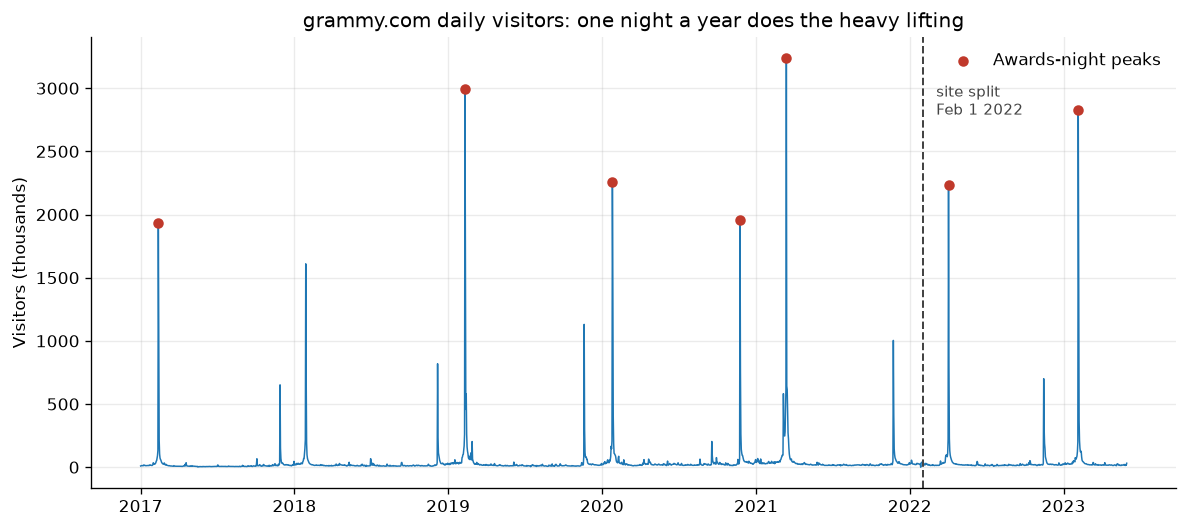

In [4]:
fig, ax = plt.subplots()
ax.plot(grammys_raw.date, grammys_raw.visitors / 1_000, color=GRAMMYS_BLUE, linewidth=0.9)
peaks = grammys_raw.nlargest(7, "visitors")
ax.scatter(peaks.date, peaks.visitors / 1_000, color="#c0392b", zorder=5, s=28,
           label="Awards-night peaks")
ax.axvline(SPLIT_DATE, color="#444", linestyle="--", linewidth=1.2)
ax.annotate("site split\nFeb 1 2022", xy=(SPLIT_DATE, ax.get_ylim()[1] * 0.82),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color="#444")
ax.set_title("grammy.com daily visitors: one night a year does the heavy lifting")
ax.set_ylabel("Visitors (thousands)")
ax.set_xlabel("")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_daily_traffic.png", bbox_inches="tight")
plt.show()

In [5]:
annual_share = (grammys_raw.assign(year=grammys_raw.date.dt.year)
                .groupby("year")
                .apply(lambda d: 100 * d.loc[d.awards_week == 1, "visitors"].sum() / d.visitors.sum(),
                       include_groups=False)
                .round(1)
                .rename("pct_of_annual_visitors"))
print("Share of each year's visitors arriving during awards week:")
print(annual_share.to_string())

Share of each year's visitors arriving during awards week:
year
2017    51.7
2018    43.1
2019    56.1
2020    43.6
2021    42.8
2022    39.7
2023    65.3


**What I take from this:** awards week is 40–65% of annual traffic every single year.
That confirms the methodological choice — comparing raw before/after totals would
have measured ceremony timing, not site quality. It is also the business problem
underneath the business problem: the organization owns an audience it only reaches
for a few days a year.

It raises one more question worth checking before moving on. Spike traffic is usually
assumed to be low-quality drive-by traffic. Is it?

In [6]:
def engagement(frame: pd.DataFrame) -> pd.Series:
    """Volume-independent engagement summary for a set of daily rows."""
    return pd.Series({
        "days": len(frame),
        "sessions": int(frame.sessions.sum()),
        "bounce_rate_pct": round(100 * frame.bounced_sessions.sum() / frame.sessions.sum(), 2),
        "pages_per_session": round(frame.pageviews.sum() / frame.sessions.sum(), 2),
        "avg_secs_on_site": round(frame.avg_session_duration_secs.mean(), 1),
    })


spike_vs_normal = pd.DataFrame({
    "Awards nights": engagement(awards_nights),
    "Regular days": engagement(regular_days),
})
spike_vs_normal

,Awards nights,Regular days
days,13.00,2329.00
sessions,22589490.00,82045619.00
bounce_rate_pct,34.05,43.24
pages_per_session,2.43,1.82
avg_secs_on_site,154.20,98.40


That result surprised me and it changed the recommendation later. Awards-night
traffic is not junk traffic — it bounces *less* (34% vs 43%) and stays roughly 57%
longer than a typical day. The problem is not that show-night visitors are
disengaged; it is that they leave and do not come back. That is a retention problem,
not an acquisition or content-quality problem.

## 2. Did the Grammys site itself improve after the split?

This is the comparison the tracking continuity makes possible: the same site, same
measurement, before and after.

In [7]:
before_after = pd.DataFrame({
    "Combined site (pre-split)": engagement(combined_site),
    "Grammys site (post-split)": engagement(grammys),
})
before_after["change"] = before_after.iloc[:, 1] - before_after.iloc[:, 0]
before_after

,Combined site (pre-split),Grammys site (post-split),change
days,1857.00,485.00,-1372.00
sessions,80414221.00,24220888.00,-56193333.00
bounce_rate_pct,41.58,40.16,-1.42
pages_per_session,1.86,2.25,0.39
avg_secs_on_site,102.90,83.00,-19.90


Two of the three metrics moved the right way — bounce rate fell 1.4 points and pages
per session rose 21% — but time on site dropped by about 20 seconds. Before reading
anything into that, I had to deal with a confound I introduced myself: the pre-split
window spans five years including every season, while the post-split window is only
16 months. Awards season is over-represented after the split, and I already showed
awards-season sessions behave differently.

So I re-ran the comparison on **matching calendar months (February–May only)**, which
holds seasonality roughly constant and makes the two windows comparable.

In [8]:
def feb_to_may(frame: pd.DataFrame, years: list[int]) -> pd.DataFrame:
    return frame[frame.date.dt.month.between(2, 5) & frame.date.dt.year.isin(years)]


like_for_like = pd.DataFrame({
    "Combined site, Feb–May 2017–21": engagement(feb_to_may(grammys_raw, [2017, 2018, 2019, 2020, 2021])),
    "Grammys site, Feb–May 2022–23": engagement(feb_to_may(grammys_raw, [2022, 2023])),
    "Academy site, Feb–May 2022–23": engagement(feb_to_may(academy, [2022, 2023])),
})
like_for_like

,"Combined site, Feb–May 2017–21","Grammys site, Feb–May 2022–23","Academy site, Feb–May 2022–23"
days,601.00,240.00,240.00
sessions,36298556.00,17140326.00,636968.00
bounce_rate_pct,42.34,38.76,45.11
pages_per_session,1.97,2.20,2.56
avg_secs_on_site,91.20,82.80,130.80


The like-for-like view is cleaner and it holds up: on the Grammys site bounce rate
improved from 42.3% to 38.8% and pages per session rose from 1.97 to 2.20, while time
on site was essentially flat (91 → 83 seconds). The engagement gain is real, it is
just smaller than the naive comparison implied.

The third column is the one I would have missed without this cut. Measured across its
whole life the Academy site bounces at 33.7%, but during awards season it bounces at
**45.1%** — worse than the Grammys site in the same window. Awards-season overflow is
landing on industry pages that were not built for it. That is a specific, fixable
finding rather than a generic "engagement is good" statement.

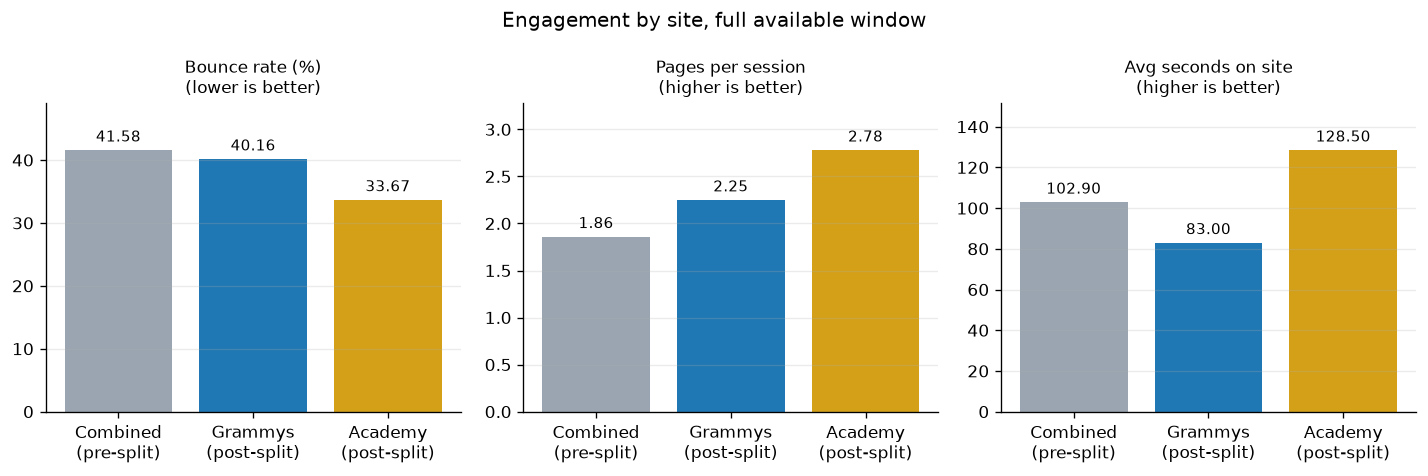

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = [("bounce_rate_pct", "Bounce rate (%)", "lower is better"),
           ("pages_per_session", "Pages per session", "higher is better"),
           ("avg_secs_on_site", "Avg seconds on site", "higher is better")]
labels = ["Combined\n(pre-split)", "Grammys\n(post-split)", "Academy\n(post-split)"]
series = [engagement(combined_site), engagement(grammys), engagement(academy)]

for ax, (key, title, direction) in zip(axes, metrics):
    values = [s[key] for s in series]
    bars = ax.bar(labels, values, color=["#9aa5b1", GRAMMYS_BLUE, ACADEMY_GOLD])
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_title(f"{title}\n({direction})", fontsize=10)
    ax.margins(y=0.18)
    ax.grid(axis="x", visible=False)

fig.suptitle("Engagement by site, full available window", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "02_engagement_by_site.png", bbox_inches="tight")
plt.show()

## 3. Is the Academy site reaching a genuinely different audience?

Better engagement on the Academy site only justifies running two properties if the
two properties serve different people. The hypothesis I was given was that the
Academy site skews older and more professional. I tested it against the age data
rather than assuming it.

In [10]:
age_grammys = pd.read_csv("data/grammys_age_demographics.csv").assign(website="Grammys")
age_academy = pd.read_csv("data/tra_age_demographics.csv").assign(website="Recording Academy")
age = pd.concat([age_grammys, age_academy], ignore_index=True)

age_wide = (age.pivot(index="age_group", columns="website", values="pct_visitors")
            .rename(columns={"Grammys": "grammys_pct", "Recording Academy": "academy_pct"}))
age_wide["difference_pp"] = (age_wide.academy_pct - age_wide.grammys_pct).round(2)
age_wide.round(2)

website,grammys_pct,academy_pct,difference_pp
age_group,,,
18-24,27.37,27.12,-0.26
25-34,24.13,26.16,2.03
35-44,18.72,19.55,0.83
45-54,13.57,13.82,0.25
55-64,9.82,8.24,-1.58
65+,6.39,5.12,-1.27


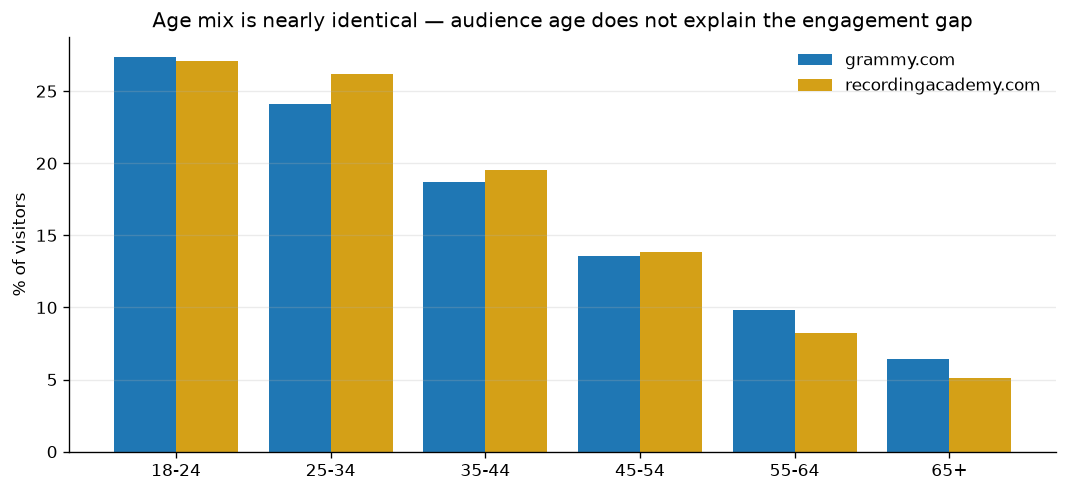

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = range(len(age_wide))
width = 0.4
ax.bar([i - width / 2 for i in x], age_wide.grammys_pct, width, label="grammy.com", color=GRAMMYS_BLUE)
ax.bar([i + width / 2 for i in x], age_wide.academy_pct, width, label="recordingacademy.com", color=ACADEMY_GOLD)
ax.set_xticks(list(x), age_wide.index)
ax.set_ylabel("% of visitors")
ax.set_title("Age mix is nearly identical — audience age does not explain the engagement gap")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(FIGURES / "03_age_demographics.png", bbox_inches="tight")
plt.show()

**This disproved the stated hypothesis.** The largest gap in any age bracket is 2.0
percentage points. The Academy site is marginally heavier in the 25–44 range (45.7%
vs 42.8%) and the Grammys site carries slightly more 55+ visitors (16.2% vs 13.4%),
but these are not two different generations. Age is not the reason one site holds
attention 55% longer than the other.

Reporting this mattered more than confirming the original assumption would have. If
the team believes the split works because of demographics, they will build the wrong
content strategy. The engagement difference has to come from **visit intent** —
people arriving at the Academy site are looking for something specific — and intent
is what the content strategy should target.

Device mix, on the other hand, is a real and actionable difference.

In [12]:
desktop = (pd.read_csv("data/desktop_users.csv")
           .rename(columns={"visitors": "desktop_visitors"})
           .drop(columns=["segment"]))
mobile = (pd.read_csv("data/mobile_users.csv")
          .rename(columns={"visitors": "mobile_visitors"})
          .drop(columns=["segment"]))

devices = desktop.merge(mobile, on="date", how="inner")
devices["total_visitors"] = devices.desktop_visitors + devices.mobile_visitors

benchmark_window = devices[devices.date.between("2023-04-01", "2023-06-30")]
desktop_share = 100 * benchmark_window.desktop_visitors.sum() / benchmark_window.total_visitors.sum()

print(f"Apr–Jun 2023, {len(benchmark_window)} days, {benchmark_window.total_visitors.sum():,} visits")
print(f"Desktop share: {desktop_share:.2f}%")
print(f"Mobile share:  {100 - desktop_share:.2f}%")

Apr–Jun 2023, 91 days, 1,428,482 visits
Desktop share: 31.84%
Mobile share:  68.16%


## 4. Benchmarking against the American Music Awards

Internal metrics have no natural scale — is a 40% bounce rate good? To answer that I
compared the Grammys numbers to published figures for the AMAs over the same
April–June 2023 window. I chose this window because it is a non-awards period for
both organizations, so neither side is inflated by its own ceremony.

In [13]:
competitor = pd.DataFrame({
    "metric": ["Bounce rate (%)", "Pages per visit", "Avg seconds on site", "Mobile share (%)"],
    "grammy.com": [engagement(grammys).bounce_rate_pct,
                   engagement(grammys).pages_per_session,
                   engagement(grammys).avg_secs_on_site,
                   round(100 - desktop_share, 1)],
    "AMAs (published)": [54.31, 2.74, 353.0, None],
}).set_index("metric")
competitor

,grammy.com,AMAs (published)
metric,,
Bounce rate (%),40.16,54.31
Pages per visit,2.25,2.74
Avg seconds on site,83.00,353.00
Mobile share (%),68.20,NaN


The Grammys site wins decisively on bounce rate (40.2% vs 54.3%) — first impressions
work. It loses badly on depth of visit: 2.25 pages and 83 seconds against 2.74 pages
and 353 seconds. Visitors are not rejecting the page, they are getting what they came
for and leaving.

That is consistent with a mobile-dominated audience: 68% of visits in this window
came from phones, which is exactly the pattern of "check the winner, close the tab."
The gap is a content-depth problem on mobile, not a landing-page problem.

## Findings

| # | Finding | Evidence |
|---|---|---|
| 1 | Traffic is extremely concentrated | Awards nights average 43x a regular day; awards week is 40–65% of annual traffic |
| 2 | Spike traffic is high quality | 34% bounce and 154 seconds on awards nights vs 43% and 98 seconds otherwise |
| 3 | The split improved the fan site | Like-for-like Feb–May: bounce 42.3% → 38.8%, pages/session 1.97 → 2.20 |
| 4 | The Academy site is the stickiest property | 128.5 seconds and 2.78 pages/session, vs 83.0 and 2.25 on the fan site |
| 5 | Demographics do not explain the gap | Largest age-bracket difference is 2.0 percentage points |
| 6 | Awards-season overflow hurts the Academy site | Academy bounce rises to 45.1% in Feb–May, worse than the fan site |
| 7 | Depth, not first impressions, is the weakness vs the AMAs | Better bounce rate (40.2% vs 54.3%), far worse duration (83s vs 353s) |

## Recommendation

**Keep the two sites separate**, and treat them as two different jobs rather than two
versions of the same job.

1. **grammy.com is a reach engine.** It is mobile-first (68% of visits) and its
   weakness is depth, not appeal. Invest in fast, mobile-native follow-on content —
   winner lists that lead into performance clips, sharable moments — to convert
   single-page visits into second and third pageviews.
2. **recordingacademy.com is a retention engine.** It carries 1.17M sessions against
   the fan site's 24.2M, but holds attention 55% longer. Judge it on depth and return
   visits, not on volume, and use it for the year-round membership and advocacy
   content that fans do not come for.
3. **Fix awards-season landing pages on the Academy site.** Its bounce rate rises to
   45.1% during February–May, which means overflow show traffic is hitting pages that
   were not designed to receive it. This is the cheapest available win.
4. **Stop treating age as the segmentation axis.** The two audiences are nearly the
   same age; they differ in intent. Segment content by why someone arrived (fan
   moment vs industry need), not by how old they are.

## Limitations

- The Academy site has no pre-split baseline, so its metrics are cross-sectional only.
- The pre-split window is 1,857 days against 485 days after; the Feb–May cut reduces
  but does not eliminate that imbalance.
- Bounce rate and session duration are measured by the site's own analytics, and a
  single-page visit that satisfies the visitor still counts as a bounce.
- The AMA figures are published aggregates, not raw data I could validate.

## How I used AI on this project

I did the analysis, chose the metrics, and wrote the conclusions myself. I used
ChatGPT as a copilot in three narrow places, and documenting them is part of the
assignment:

1. **Syntax lookups** — for example, formatting a number to two decimals inside an
   f-string. Faster than searching documentation, no bearing on the analysis.
2. **Drafting the stakeholder memo.** My prompt:

   > *Act as a Senior Data Analyst. Based on the fact that separating grammy.com
   > (fans, high bounce rate) and recordingacademy.com (industry, low bounce rate)
   > resulted in better targeted engagement, draft a two-paragraph business memo to
   > VP Ray Starck recommending that we keep the websites separate and continue
   > tailoring content to these distinct audiences.*

3. **Reviewing the draft.** The model produced clean, logically ordered prose, but it
   inherited an assumption from my own prompt — that the audiences differ by age and
   professional status. My demographic analysis had already shown they do not. It also
   could not know about the awards-season bounce spike on the Academy site, which is
   the most actionable finding in the report. I rewrote the recommendation to correct
   the audience claim and to lead with the findings the data actually supports.

The lesson I took from that: an AI draft is only as good as the framing you give it,
and it will confidently repeat a wrong premise back to you. Verifying the premise
against the data is the analyst's job, not the model's.